# EDA — Asset Allocation Performance Forecasting

Structure, sanity checks, descriptive statistics, target, missingness, distributions, outliers, feature/target association, train/test comparison, then baselines under a grouped CV harness.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score
import lightgbm as lgbm

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

## Load

In [2]:
X_train = pd.read_csv('../data/raw/X_train.csv', index_col='ROW_ID')
y_train = pd.read_csv('../data/raw/y_train.csv', index_col='ROW_ID')
X_test = pd.read_csv('../data/raw/X_test.csv', index_col='ROW_ID')

df = X_train.join(y_train)

RET = [f'RET_{i}' for i in range(1, 21)]
SV = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]
NUMERIC = RET + SV + ['MEDIAN_DAILY_TURNOVER']

X_train.shape, X_test.shape

((527073, 44), (31870, 44))

In [3]:
df.dtypes

TS                           str
ALLOCATION                   str
RET_20                   float64
RET_19                   float64
RET_18                   float64
RET_17                   float64
RET_16                   float64
RET_15                   float64
RET_14                   float64
RET_13                   float64
RET_12                   float64
RET_11                   float64
RET_10                   float64
RET_9                    float64
RET_8                    float64
RET_7                    float64
RET_6                    float64
RET_5                    float64
RET_4                    float64
RET_3                    float64
RET_2                    float64
RET_1                    float64
SIGNED_VOLUME_20         float64
SIGNED_VOLUME_19         float64
SIGNED_VOLUME_18         float64
SIGNED_VOLUME_17         float64
SIGNED_VOLUME_16         float64
SIGNED_VOLUME_15         float64
SIGNED_VOLUME_14         float64
SIGNED_VOLUME_13         float64
SIGNED_VOL

## Sanity checks

In [4]:
print('duplicate ROW_ID:', df.index.duplicated().sum())
print('duplicate (TS, ALLOCATION) pairs:', df.duplicated(subset=['TS', 'ALLOCATION']).sum())
print('fully duplicate rows:', df.duplicated().sum())
print('constant columns:', [c for c in df.columns if df[c].nunique(dropna=True) <= 1])
print('y_train target nulls:', y_train['target'].isna().sum())

duplicate ROW_ID: 0
duplicate (TS, ALLOCATION) pairs: 0


fully duplicate rows: 0


constant columns: []
y_train target nulls: 0


No duplicate keys, no duplicate rows, no constant columns, no missing targets — the panel is exactly as described, nothing to drop or de-dupe before modelling.

## Descriptive statistics

In [5]:
desc = df[NUMERIC + ['target']].describe().T
desc['skew'] = df[NUMERIC + ['target']].skew()
desc['kurtosis'] = df[NUMERIC + ['target']].kurtosis()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
RET_1,527073.0,0.000079,0.003041,-3.935147e-02,-0.001444,0.000062,0.001600,0.129314,0.384282,18.440142
RET_2,527073.0,0.000042,0.003068,-4.372330e-02,-0.001496,0.000038,0.001598,0.129412,0.280378,16.883282
RET_3,527073.0,0.000038,0.003058,-4.367603e-02,-0.001501,0.000038,0.001596,0.129798,0.244754,16.510978
RET_4,527073.0,0.000034,0.003051,-4.235460e-02,-0.001507,0.000035,0.001592,0.131141,0.235472,16.606573
RET_5,527073.0,0.000032,0.003042,-4.362071e-02,-0.001505,0.000035,0.001588,0.129787,0.228863,16.133935
RET_6,527073.0,0.000028,0.003047,-4.356928e-02,-0.001512,0.000032,0.001589,0.130090,0.215432,16.000794
RET_7,527073.0,0.000026,0.003048,-4.407607e-02,-0.001513,0.000031,0.001588,0.129792,0.230025,16.228079
RET_8,527073.0,0.000026,0.003047,-4.365150e-02,-0.001517,0.000029,0.001589,0.129302,0.228775,16.373770
RET_9,527073.0,0.000026,0.003049,-4.343652e-02,-0.001516,0.000030,0.001591,0.129456,0.232024,16.276610
RET_10,527071.0,0.000023,0.003056,-4.620820e-02,-0.001523,0.000028,0.001594,0.129320,0.216857,16.187769


Every `RET_i` and `SIGNED_VOLUME_i` is centered near zero with a similar spread across lags (consistent with the correlation-matrix view later on). `SIGNED_VOLUME_i` is the most heavy-tailed block by far (kurtosis in the hundreds), `MEDIAN_DAILY_TURNOVER` is bounded at 0 with a long right tail (positive skew ≈ 4.3), and `target` is close to symmetric (skew ≈ 0) but still fat-tailed (kurtosis ≈ 7.7) relative to a normal distribution.

## Panel structure

Each row is a `(TS, ALLOCATION)` snapshot. Check how balanced that panel is, and whether train/test share allocations or dates.

In [6]:
print('unique TS (train/test):', X_train.TS.nunique(), X_test.TS.nunique())
print('unique ALLOCATION (train/test):', X_train.ALLOCATION.nunique(), X_test.ALLOCATION.nunique())
print('unique GROUP:', X_train.GROUP.nunique())
print('TS overlap train/test:', len(set(X_train.TS) & set(X_test.TS)))
print('ALLOCATION overlap train/test:', len(set(X_train.ALLOCATION) & set(X_test.ALLOCATION)))

unique TS (train/test): 2522 120
unique ALLOCATION (train/test): 278 278
unique GROUP: 4
TS overlap train/test: 0
ALLOCATION overlap train/test: 278


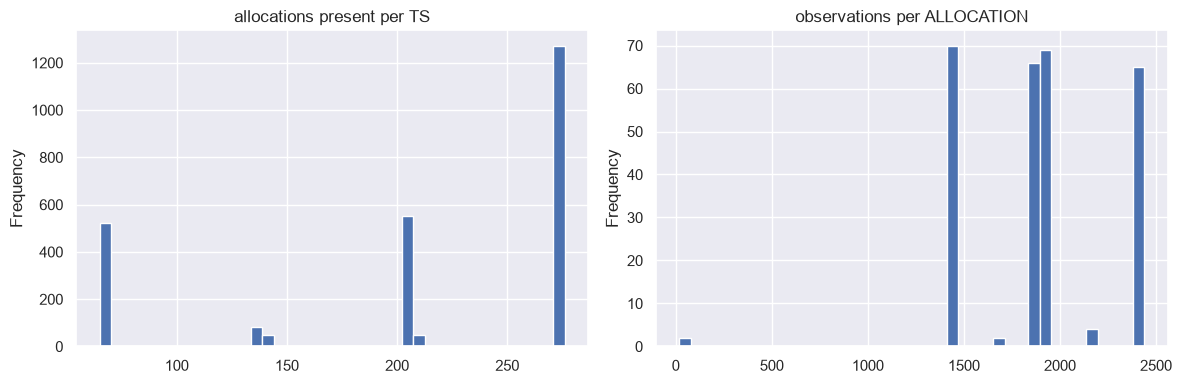

In [7]:
rows_per_ts = X_train.groupby('TS').size()
rows_per_alloc = X_train.groupby('ALLOCATION').size()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rows_per_ts.plot(kind='hist', bins=40, ax=axes[0], title='allocations present per TS')
rows_per_alloc.plot(kind='hist', bins=40, ax=axes[1], title='observations per ALLOCATION')
plt.tight_layout()

The panel is unbalanced: allocations enter and leave the universe over time rather than all 278 being present on every date, and individual allocations range from a handful of observations to the full history length.

## TS ordering

Dates are anonymized as `DATE_0001`, `DATE_0002`, ... The challenge statement says continuity isn't guaranteed. Check whether the numeric suffix still encodes any real chronological signal, the way a similar trick did in a sibling QRT challenge.

In [8]:
tmp = df.sort_values(['ALLOCATION', 'TS']).copy()
tmp['ts_num'] = tmp['TS'].str.extract(r'(\d+)').astype(int)
tmp['prev_ts_num'] = tmp.groupby('ALLOCATION')['ts_num'].shift(1)
tmp['prev_target'] = tmp.groupby('ALLOCATION')['target'].shift(1)
tmp['gap'] = tmp['ts_num'] - tmp['prev_ts_num']

print('TS-label gap distribution for consecutive rows of the same allocation:')
print(tmp['gap'].value_counts(normalize=True).head())

adjacent = tmp[tmp['gap'] == 1]
print()
print('corr(RET_1, previous row target) restricted to label-adjacent rows:',
      adjacent['RET_1'].corr(adjacent['prev_target']))

TS-label gap distribution for consecutive rows of the same allocation:
gap
1.0    0.781581
2.0    0.151311
3.0    0.043264
4.0    0.015799
5.0    0.005327
Name: proportion, dtype: float64

corr(RET_1, previous row target) restricted to label-adjacent rows: 0.0016778608881427822


Zero correlation even when the numeric label gap is exactly 1: unlike `DAY_ID` in the electricity challenge, the `TS` numbering here carries no recoverable calendar order. Treat dates as genuinely exchangeable and do not build lag/ordering features off the `TS` label.

## Target

In [9]:
df['target'].describe()

count    527073.000000
mean          0.000035
std           0.003106
min          -0.051809
25%          -0.001517
50%           0.000041
75%           0.001600
max           0.051803
Name: target, dtype: float64

positive share: 0.5071840143585423


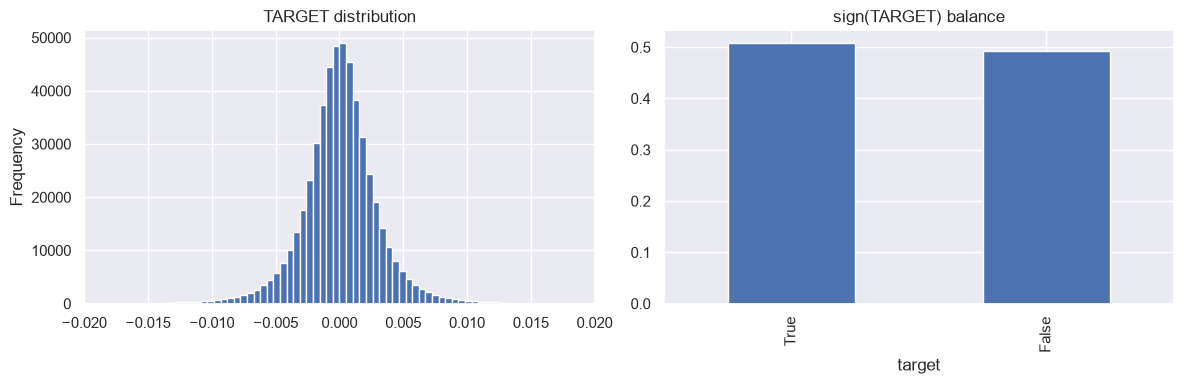

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['target'].plot(kind='hist', bins=200, ax=axes[0], title='TARGET distribution')
axes[0].set_xlim(-0.02, 0.02)
(df['target'] > 0).value_counts(normalize=True).plot(kind='bar', ax=axes[1], title='sign(TARGET) balance')
plt.tight_layout()

print('positive share:', (df['target'] > 0).mean())

Sign balance sits close to 50/50 (50.7% positive), so accuracy has a majority-class floor around 0.507 and any real signal is a small edge on top of that.

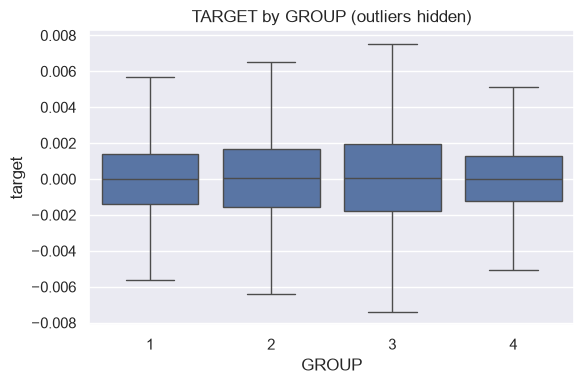

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='GROUP', y='target', ax=ax, showfliers=False)
ax.set_title('TARGET by GROUP (outliers hidden)')
plt.tight_layout()

## Missing data

In [12]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_frac = (miss / len(df)).rename('frac_missing')
miss_frac.to_frame()

,frac_missing
SIGNED_VOLUME_1,0.735204
SIGNED_VOLUME_20,0.016123
MEDIAN_DAILY_TURNOVER,0.006902
SIGNED_VOLUME_19,0.005696
SIGNED_VOLUME_18,0.001630
RET_20,0.000110
SIGNED_VOLUME_17,0.000110
RET_19,0.000095
SIGNED_VOLUME_16,0.000095
RET_18,0.000080


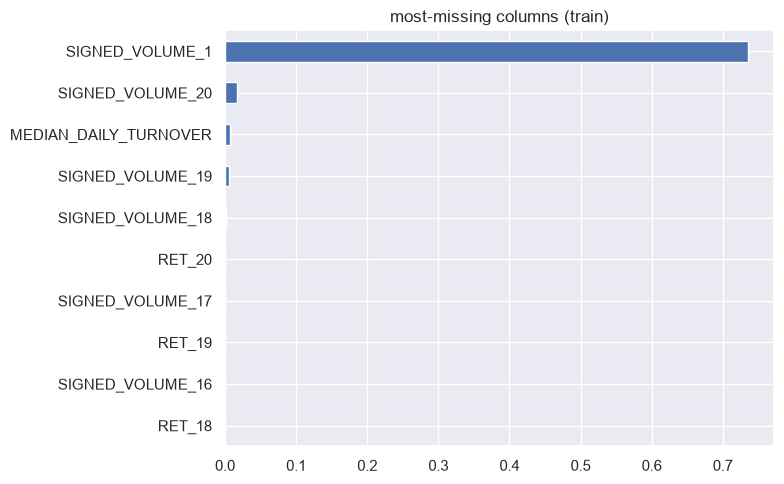

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
miss_frac.head(10).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('most-missing columns (train)')
plt.tight_layout()

`SIGNED_VOLUME_1` is missing for 73.5% of rows — far more than any other column. Check whether that's random or structural.

allocations always reporting SIGNED_VOLUME_1: 24
allocations missing it ~80% of the time: 254


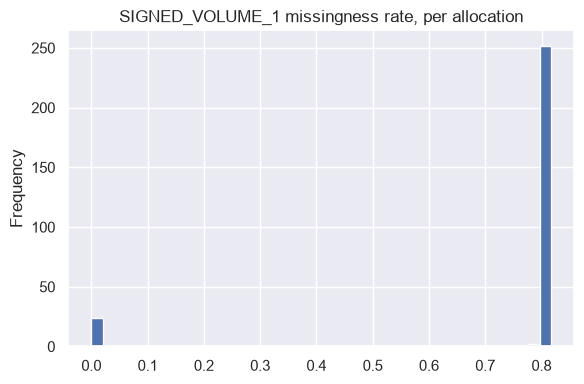

In [14]:
frac_missing_by_alloc = df.groupby('ALLOCATION')['SIGNED_VOLUME_1'].apply(lambda s: s.isna().mean())
frac_missing_by_alloc.plot(kind='hist', bins=40, figsize=(6, 4), title='SIGNED_VOLUME_1 missingness rate, per allocation')
plt.tight_layout()

print('allocations always reporting SIGNED_VOLUME_1:', (frac_missing_by_alloc == 0).sum())
print('allocations missing it ~80% of the time:', (frac_missing_by_alloc > 0.7).sum())

Bimodal, not random: 24 allocations (6 per `GROUP`) always report `SIGNED_VOLUME_1`, and the rest are missing it on roughly 4 out of 5 days. This looks like a per-allocation reporting-lag artifact rather than missing-at-random noise, so it's a signal in its own right (e.g. a `SIGNED_VOLUME_1`-is-missing indicator), not just something to impute away.

## GROUP

In [15]:
alloc_group_nunique = df.groupby('ALLOCATION')['GROUP'].nunique()
print('allocations with more than one GROUP over their history:', (alloc_group_nunique > 1).sum())

group_stats = pd.DataFrame({
    'n_alloc': df.groupby('GROUP')['ALLOCATION'].nunique(),
    'n_rows': df.groupby('GROUP').size(),
    'target_std': df.groupby('GROUP')['target'].std(),
    'turnover_median': df.groupby('GROUP')['MEDIAN_DAILY_TURNOVER'].median(),
    'target_positive_share': df.groupby('GROUP')['target'].apply(lambda s: (s > 0).mean()),
})
group_stats

allocations with more than one GROUP over their history: 0


,n_alloc,n_rows,target_std,turnover_median,target_positive_share
GROUP,,,,,
1,70,100170,0.003131,0.014892,0.500519
2,70,134928,0.003093,0.016867,0.509783
3,70,168913,0.003464,0.016498,0.509919
4,68,123062,0.002527,0.015318,0.506005


`GROUP` is a fixed attribute of the allocation (never changes over its history), and the 4 groups differ meaningfully in return volatility and typical turnover — plausibly different allocation styles (e.g. trend-following vs. mean-reversion vs. carry).

## Distributions

`RET_1`, `SIGNED_VOLUME_1`, and `MEDIAN_DAILY_TURNOVER` — the most recent, most-correlated-with-target instance of each feature family.

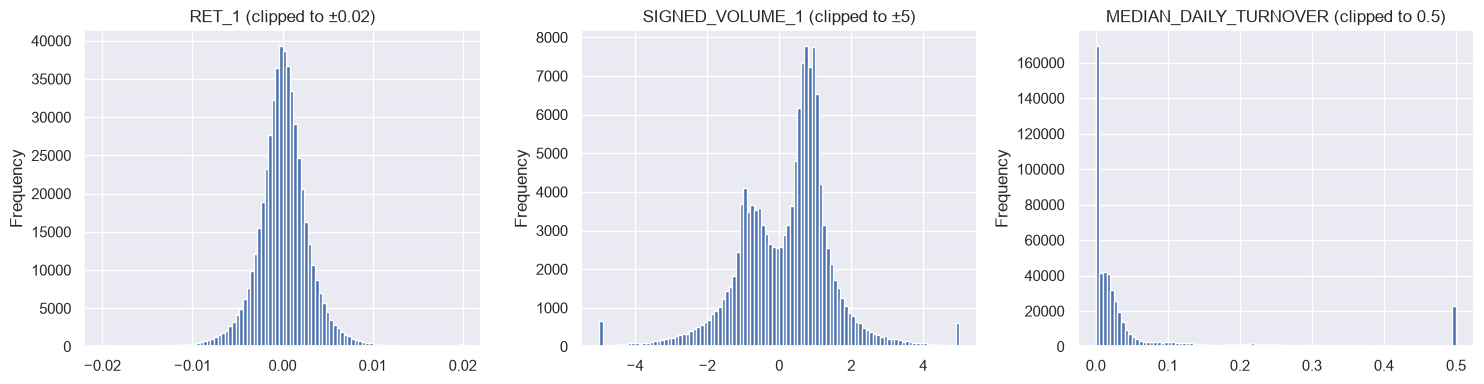

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['RET_1'].clip(-0.02, 0.02).plot(kind='hist', bins=100, ax=axes[0], title='RET_1 (clipped to ±0.02)')
df['SIGNED_VOLUME_1'].clip(-5, 5).plot(kind='hist', bins=100, ax=axes[1], title='SIGNED_VOLUME_1 (clipped to ±5)')
df['MEDIAN_DAILY_TURNOVER'].clip(0, 0.5).plot(kind='hist', bins=100, ax=axes[2], title='MEDIAN_DAILY_TURNOVER (clipped to 0.5)')
plt.tight_layout()

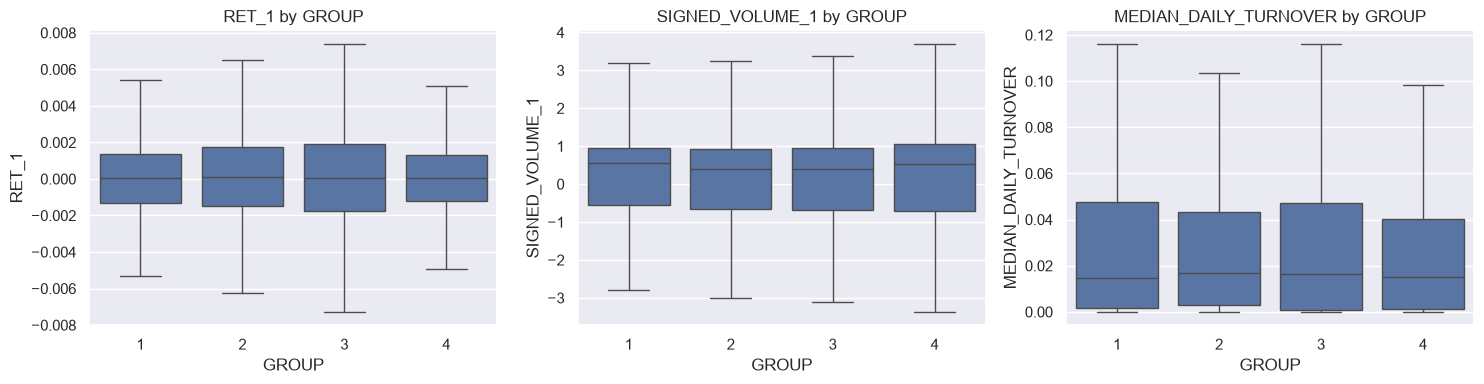

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='GROUP', y='RET_1', ax=axes[0], showfliers=False)
sns.boxplot(data=df, x='GROUP', y='SIGNED_VOLUME_1', ax=axes[1], showfliers=False)
sns.boxplot(data=df, x='GROUP', y='MEDIAN_DAILY_TURNOVER', ax=axes[2], showfliers=False)
for ax, title in zip(axes, ['RET_1 by GROUP', 'SIGNED_VOLUME_1 by GROUP', 'MEDIAN_DAILY_TURNOVER by GROUP']):
    ax.set_title(title)
plt.tight_layout()

`GROUP` 3 runs both wider returns and higher turnover — consistent with it being a more actively-rebalanced, higher-volatility style; `GROUP` 4 is the tightest on both.

## Outliers

Fraction of each column beyond 3×IQR from the quartiles (a wide, deliberately generous whisker so this flags genuine tail events rather than routine spread).

In [18]:
outlier_rows = []
for c in ['RET_1', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'target']:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    outlier_rows.append((c, (df[c] < lo).mean(), (df[c] > hi).mean()))

outliers = pd.DataFrame(outlier_rows, columns=['column', 'frac_below', 'frac_above']).set_index('column')
outliers['frac_total'] = outliers['frac_below'] + outliers['frac_above']
outliers

,frac_below,frac_above,frac_total
column,,,
RET_1,0.004091,0.004106,0.008196
SIGNED_VOLUME_1,0.000886,0.000742,0.001628
MEDIAN_DAILY_TURNOVER,0.000000,0.133304,0.133304
target,0.004419,0.004174,0.008593


In [19]:
df.reindex(df['RET_1'].abs().sort_values(ascending=False).index).head(5)[['TS', 'ALLOCATION', 'GROUP', 'RET_1', 'target']]

,TS,ALLOCATION,GROUP,RET_1,target
ROW_ID,,,,,
453636,DATE_2168,ALLOCATION_185,2,0.129314,0.001913
325129,DATE_1546,ALLOCATION_185,2,0.111031,0.003410
490708,DATE_2352,ALLOCATION_185,2,0.062400,-0.003195
515343,DATE_2471,ALLOCATION_185,2,0.060450,0.002409
346042,DATE_1641,ALLOCATION_185,2,0.056846,-0.004576


`MEDIAN_DAILY_TURNOVER` has the heaviest outlier rate (13.3% beyond the whiskers) — expected for a quantity bounded at 0 with a long right tail. `RET_1` and `SIGNED_VOLUME_1` tails are thin by count (<1%) but extreme in magnitude (`RET_1` reaches 0.13 against a std of 0.003, a >40σ move) — real, rare dislocations rather than a data-quality issue, worth robust-scaling or winsorizing for linear models but not dropping.

## Feature / target association

corr(MEDIAN_DAILY_TURNOVER, target): 0.01340517878565219


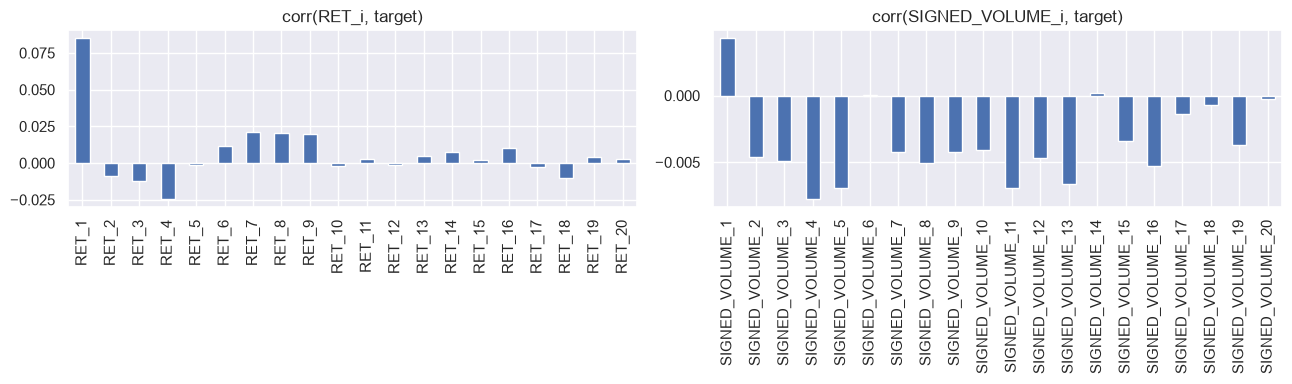

In [20]:
ret_corr = df[RET + ['target']].corr()['target'].drop('target')
sv_corr = df[SV + ['target']].corr()['target'].drop('target')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ret_corr.plot(kind='bar', ax=axes[0], title='corr(RET_i, target)')
sv_corr.plot(kind='bar', ax=axes[1], title='corr(SIGNED_VOLUME_i, target)')
plt.tight_layout()

print('corr(MEDIAN_DAILY_TURNOVER, target):', df['MEDIAN_DAILY_TURNOVER'].corr(df['target']))

`RET_1` (yesterday's return) stands out at corr ≈ 0.085 — well above every other lag and above every `SIGNED_VOLUME_i`, which all sit near zero. That's short-term continuation, not mean-reversion. Turnover and volume carry essentially no linear sign information individually.

In [21]:
naive_preds = {
    'majority_class': pd.Series((df['target'] > 0).mean() > 0.5, index=df.index).astype(int),
    'sign(RET_1)': (df['RET_1'] > 0).astype(int),
    'sign(mean RET_1:5)': (df[RET[:5]].mean(axis=1) > 0).astype(int),
    'sign(mean RET_1:20)': (df[RET].mean(axis=1) > 0).astype(int),
}
target_sign = (df['target'] > 0).astype(int)

for name, pred in naive_preds.items():
    print(f'{name:22s} accuracy = {accuracy_score(target_sign, pred):.4f}')

majority_class         accuracy = 0.5072
sign(RET_1)            accuracy = 0.5189
sign(mean RET_1:5)     accuracy = 0.5056
sign(mean RET_1:20)    accuracy = 0.5082


`sign(RET_1)` alone reaches ~51.9% accuracy on the full training set — already ahead of the published LightGBM benchmark's 0.5079 public score, and averaging over more lags (`mean RET_1:5`, `mean RET_1:20`) washes the signal back out. Recency, not smoothing, is what carries the edge here.

In [22]:
group_acc = df.groupby('GROUP').apply(
    lambda d: accuracy_score((d['target'] > 0).astype(int), (d['RET_1'] > 0).astype(int))
).rename('acc_sign_ret1')
group_corr = df.groupby('GROUP').apply(lambda d: d['RET_1'].corr(d['target'])).rename('corr_ret1_target')
pd.concat([group_corr, group_acc], axis=1)

,corr_ret1_target,acc_sign_ret1
GROUP,,
1,0.117877,0.523111
2,0.082952,0.521864
3,0.075428,0.514650
4,0.073262,0.518162


The `RET_1` → `target` edge holds in every `GROUP`, strongest in `GROUP` 1.

## Lag structure and volume

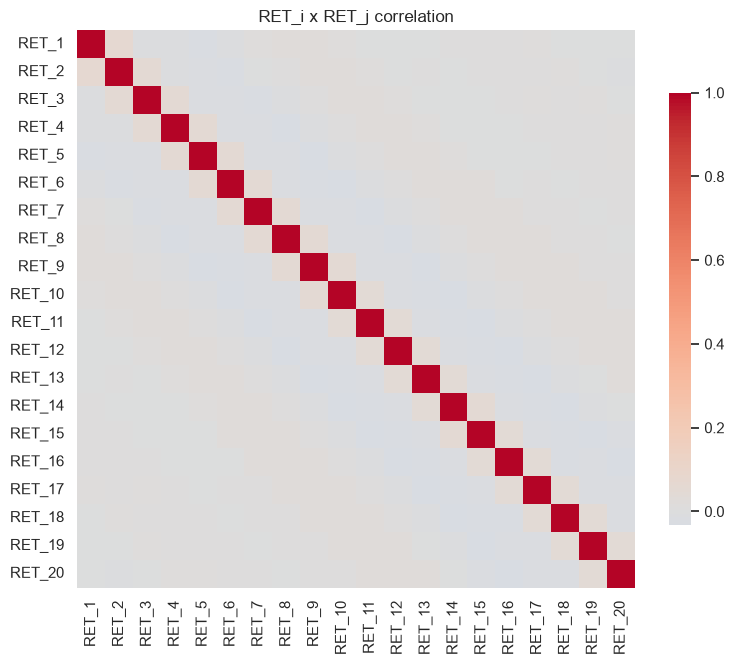

In [23]:
ret_corr_matrix = df[RET].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(ret_corr_matrix, cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('RET_i x RET_j correlation')
plt.tight_layout()

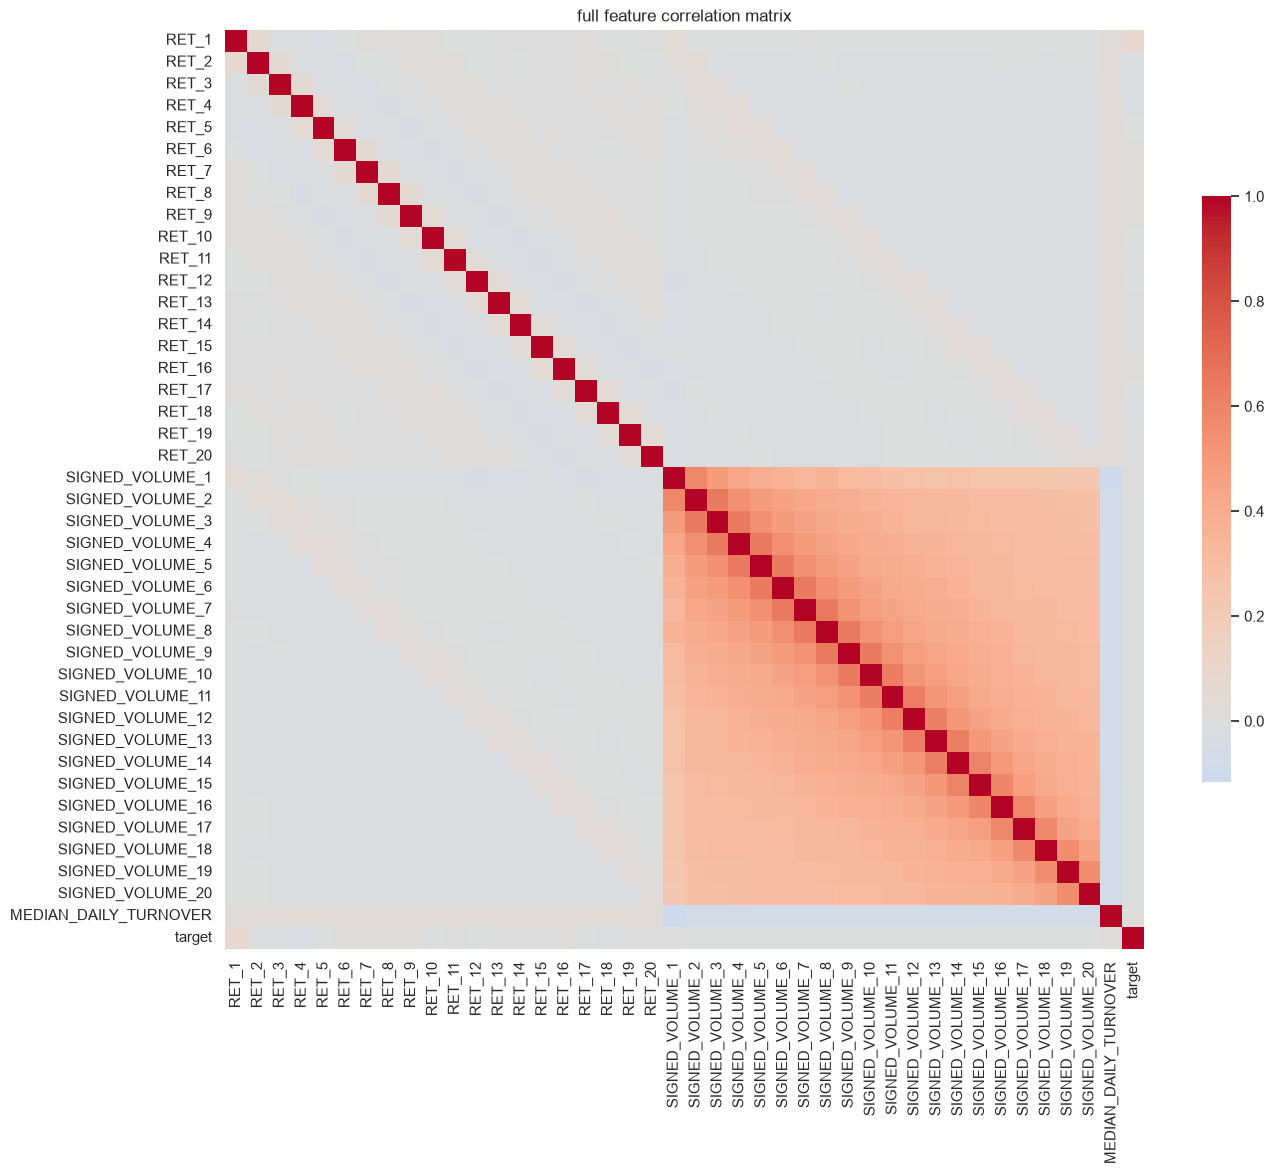

In [24]:
full_corr = df[NUMERIC + ['target']].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(full_corr, cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink': 0.6})
ax.set_title('full feature correlation matrix')
plt.tight_layout()

Two clean blocks: `RET_*` and `SIGNED_VOLUME_*` are each internally near-uncorrelated across lags (no visible decay pattern), and the two blocks barely correlate with each other. `target` lights up faintly only against `RET_1` — everything else in the 41×41 grid is close to noise.

In [25]:
same_day_ret_vol_corr = np.mean([df[f'RET_{i}'].corr(df[f'SIGNED_VOLUME_{i}']) for i in range(1, 21)])
print('avg corr(RET_i, SIGNED_VOLUME_i), same day:', same_day_ret_vol_corr)
print('corr(MEDIAN_DAILY_TURNOVER, |target|):', df['MEDIAN_DAILY_TURNOVER'].corr(df['target'].abs()))
print('corr(MEDIAN_DAILY_TURNOVER, |RET_1|):', df['MEDIAN_DAILY_TURNOVER'].corr(df['RET_1'].abs()))

avg corr(RET_i, SIGNED_VOLUME_i), same day: 0.031293300864403045
corr(MEDIAN_DAILY_TURNOVER, |target|): 0.03524288774476034
corr(MEDIAN_DAILY_TURNOVER, |RET_1|): 0.035055470754433105


Same-day return/volume are essentially uncorrelated. Turnover has a small positive relationship with return *magnitude* (both `|target|` and `|RET_1|`) — consistent with the benchmark's own volatility features, and with turnover being a magnitude signal rather than a directional one.

## Cross-sectional (same-day) effects

In [26]:
same_day_mean_target = df.groupby('TS')['target'].transform('mean')
same_day_mean_ret1 = df.groupby('TS')['RET_1'].transform('mean')

print('corr(target, same-day mean target across allocations):', np.corrcoef(df['target'], same_day_mean_target)[0, 1])
print('corr(target, same-day mean RET_1 across allocations):  ', np.corrcoef(df['target'], same_day_mean_ret1)[0, 1])
print('accuracy of sign(same-day mean RET_1):', accuracy_score(target_sign, (same_day_mean_ret1 > 0).astype(int)))

corr(target, same-day mean target across allocations): 0.2569280461820429
corr(target, same-day mean RET_1 across allocations):   0.036906227329465496
accuracy of sign(same-day mean RET_1): 0.5063131672462827


Same-day targets across allocations correlate at 0.26 — a real shared daily factor, not independent draws. That factor isn't usable as a feature directly (it's built from the labels you're trying to predict), but it's why the benchmark's `ALLOCATIONS_AVERAGE_PERF_i` features (same-day average of *past* returns, no leakage) are worth having, and why cross-validation has to be grouped by `TS` — a row-random split would let a fold see other allocations' outcomes on a date whose shared factor it's also trying to predict elsewhere.

## Train vs test comparison

No `TS` overlap between train and test (checked above), so it's worth confirming the two sets are at least drawn from a similar distribution before trusting a CV estimate to transfer.

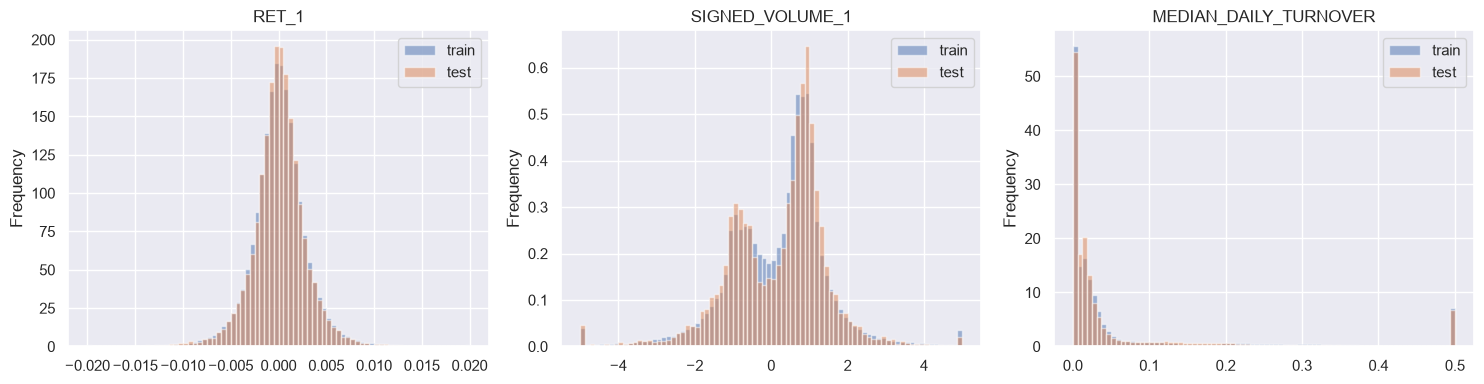

In [27]:
compare_cols = ['RET_1', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clips = {'RET_1': (-0.02, 0.02), 'SIGNED_VOLUME_1': (-5, 5), 'MEDIAN_DAILY_TURNOVER': (0, 0.5)}
for ax, c in zip(axes, compare_cols):
    lo, hi = clips[c]
    X_train[c].clip(lo, hi).plot(kind='hist', bins=80, density=True, alpha=0.5, ax=ax, label='train')
    X_test[c].clip(lo, hi).plot(kind='hist', bins=80, density=True, alpha=0.5, ax=ax, label='test')
    ax.set_title(c)
    ax.legend()
plt.tight_layout()

In [28]:
pd.DataFrame({
    'train_mean': X_train[compare_cols].mean(),
    'test_mean': X_test[compare_cols].mean(),
    'train_std': X_train[compare_cols].std(),
    'test_std': X_test[compare_cols].std(),
    'train_missing_rate': X_train[compare_cols].isna().mean(),
    'test_missing_rate': X_test[compare_cols].isna().mean(),
})

,train_mean,test_mean,train_std,test_std,train_missing_rate,test_missing_rate
RET_1,0.000079,0.000056,0.003041,0.002976,0.000000,0.000000
SIGNED_VOLUME_1,0.195340,0.184540,1.495215,1.461501,0.735204,0.750361
MEDIAN_DAILY_TURNOVER,0.090944,0.085409,0.236489,0.233175,0.006902,0.004675


In [29]:
group_composition = pd.concat([
    X_train.groupby('ALLOCATION')['GROUP'].first().value_counts(normalize=True),
    X_test.groupby('ALLOCATION')['GROUP'].first().value_counts(normalize=True),
], axis=1, keys=['train', 'test'])
group_composition

,train,test
GROUP,,
1,0.251799,0.251799
2,0.251799,0.251799
3,0.251799,0.251799
4,0.244604,0.244604


Distributions, means, and spreads line up closely between train and test, `GROUP` composition is identical (same 278 allocations both sides), and only `SIGNED_VOLUME_1`'s missing rate drifts a little (73.5% train vs 75.0% test). No meaningful covariate shift — a `TS`-grouped CV score on train should be a reasonable proxy for test performance.

## Example trajectories

A handful of individual `(TS, ALLOCATION)` snapshots, plotting their `RET_20 .. RET_1` history as a path — what the model actually sees as input for one row.

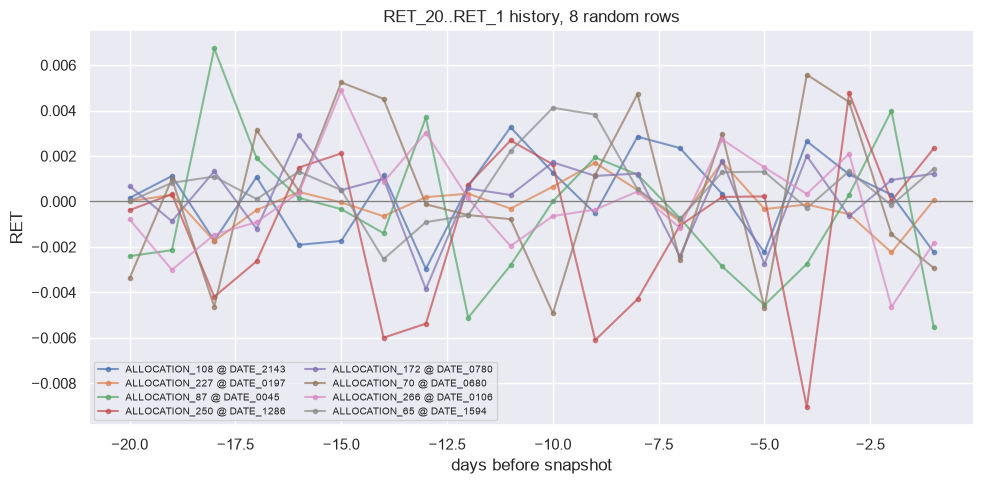

In [30]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(df.index, size=8, replace=False)

fig, ax = plt.subplots(figsize=(10, 5))
for idx in sample_idx:
    row = df.loc[idx]
    ax.plot(range(-20, 0), row[RET].to_numpy(), marker='o', markersize=3, alpha=0.7,
            label=f"{row['ALLOCATION']} @ {row['TS']}")
ax.axhline(0, color='grey', linewidth=1)
ax.set_xlabel('days before snapshot')
ax.set_ylabel('RET')
ax.set_title('RET_20..RET_1 history, 8 random rows')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()

No visible trend, cycle, or momentum shape at a glance — reinforcing the lag-correlation finding above that the 20-day return path looks like noise around zero except for the last observation, `RET_1`.

## Baselines under grouped CV

`GroupKFold` on `TS` so no date appears in both the train and validation side of a fold — matching the train/test split, which shares no dates.

In [31]:
features = RET + SV + ['MEDIAN_DAILY_TURNOVER']
Xf = df[features].fillna(0).to_numpy()
y = df['target'].to_numpy()
y_sign = (y > 0).astype(int)
groups = df['TS'].to_numpy()

gkf = GroupKFold(n_splits=5)
results = {name: [] for name in ['majority', 'sign(RET_1)', 'ridge', 'lightgbm']}

ret1 = df['RET_1'].to_numpy()

for fold, (train_idx, val_idx) in enumerate(gkf.split(Xf, y, groups)):
    y_val_sign = y_sign[val_idx]

    majority_val = int(y_sign[train_idx].mean() > 0.5)
    results['majority'].append(accuracy_score(y_val_sign, np.full(len(val_idx), majority_val)))

    results['sign(RET_1)'].append(accuracy_score(y_val_sign, (ret1[val_idx] > 0).astype(int)))

    ridge = Ridge(alpha=1.0)
    ridge.fit(Xf[train_idx], y[train_idx])
    results['ridge'].append(accuracy_score(y_val_sign, (ridge.predict(Xf[val_idx]) > 0).astype(int)))

    lgbm_params = {'objective': 'mse', 'metric': 'mse', 'verbosity': -1, 'seed': 42,
                    'learning_rate': 1e-2, 'max_depth': 3}
    train_set = lgbm.Dataset(Xf[train_idx], label=y[train_idx])
    model = lgbm.train(lgbm_params, train_set, num_boost_round=300)
    results['lightgbm'].append(accuracy_score(y_val_sign, (model.predict(Xf[val_idx]) > 0).astype(int)))

    print(f'fold {fold + 1} done')

cv_results = pd.DataFrame(results)
cv_results.index.name = 'fold'
cv_results

fold 1 done


fold 2 done


fold 3 done


fold 4 done


fold 5 done


,majority,sign(RET_1),ridge,lightgbm
fold,,,,
0,0.507172,0.519599,0.518992,0.523612
1,0.509079,0.523033,0.521288,0.524893
2,0.508932,0.516046,0.521122,0.520666
3,0.507703,0.521230,0.521325,0.524341
4,0.503036,0.514713,0.517530,0.518128


In [32]:
summary = cv_results.agg(['mean', 'std']).T
summary

,mean,std
majority,0.507184,0.002456
sign(RET_1),0.518924,0.003488
ridge,0.520051,0.001716
lightgbm,0.522328,0.002858


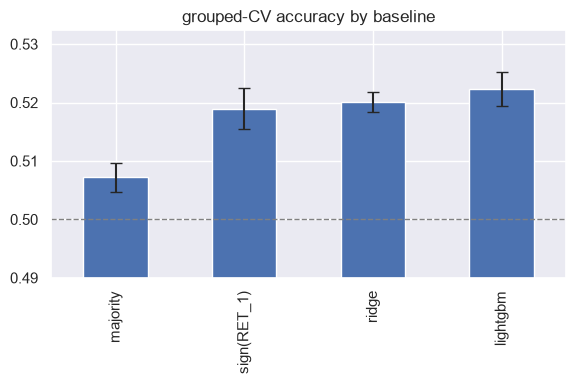

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
summary['mean'].plot(kind='bar', yerr=summary['std'], ax=ax, capsize=4)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_title('grouped-CV accuracy by baseline')
ax.set_ylim(0.49, summary['mean'].max() + 0.01)
plt.tight_layout()

`sign(RET_1)` is a strong, nearly-free baseline — on par with or ahead of a Ridge/LightGBM fit on the full 41-feature set. The main modelling opportunity looks less like squeezing signal out of `RET_2..RET_20` and `SIGNED_VOLUME_*` (both close to uncorrelated with the target individually) and more like combining `RET_1` cleanly with the `GROUP`-level and cross-sectional structure above, and treating `SIGNED_VOLUME_1`'s missingness as a feature rather than an imputation target.